#  A/B Тест: Анализ маркетинговой кампании

**Датасет:** Marketing A/B Testing (Kaggle) — 588,101 пользователей  
**Инструменты:** Python, pandas, scipy, matplotlib  
**Цель:** определить влияет ли реклама на конверсию пользователей

---

### План работы
1. Загрузка данных
2. EDA — анализ групп
3. Формулировка гипотез
4. Статистический тест
5. Доверительный интервал
6. Визуализация
7. Выводы

## 1. Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('marketing_AB.csv')
print(df.shape)
print(df.dtypes)
df.head()

(588101, 7)
Unnamed: 0       int64
user id          int64
test group         str
converted         bool
total ads        int64
most ads day       str
most ads hour    int64
dtype: object


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## 2. Чистка данных

In [2]:
df = df.drop(columns=['Unnamed: 0'])
df.columns = ['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']

print(f"Пропуски:\n{df.isnull().sum()}")
print(f"\nДубликаты: {df.duplicated().sum()}")
print(f"\nГруппы:\n{df['test_group'].value_counts()}")
print(f"\nКонверсия:\n{df['converted'].value_counts()}")

Пропуски:
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

Дубликаты: 0

Группы:
test_group
ad     564577
psa     23524
Name: count, dtype: int64

Конверсия:
converted
False    573258
True      14843
Name: count, dtype: int64


## 3. EDA — анализ групп

In [3]:
conversion_by_group = df.groupby('test_group')['converted'].agg(['sum', 'count', 'mean']).reset_index()
conversion_by_group.columns = ['group', 'conversions', 'total', 'conversion_rate']
conversion_by_group['conversion_rate'] = conversion_by_group['conversion_rate'].round(4)
display(conversion_by_group)

print(f"\nКонверсия ad группы: {conversion_by_group[conversion_by_group['group']=='ad']['conversion_rate'].values[0]*100:.2f}%")
print(f"Конверсия psa группы: {conversion_by_group[conversion_by_group['group']=='psa']['conversion_rate'].values[0]*100:.2f}%")

,group,conversions,total,conversion_rate
0,ad,14423,564577,0.0255
1,psa,420,23524,0.0179



Конверсия ad группы: 2.55%
Конверсия psa группы: 1.79%


## 4. Формулировка гипотез

**H0 (нулевая гипотеза):** реклама не влияет на конверсию — разница между группами случайная  
**H1 (альтернативная гипотеза):** реклама увеличивает конверсию  
**Уровень значимости:** α = 0.05

In [8]:
ad_group = df[df['test_group'] == 'ad']
psa_group = df[df['test_group'] == 'psa']

ad_conversions = ad_group['converted'].sum()
ad_total = len(ad_group)
psa_conversions = psa_group['converted'].sum()
psa_total = len(psa_group)

ad_rate = ad_conversions / ad_total
psa_rate = psa_conversions / psa_total

pooled_rate = (ad_conversions + psa_conversions) / (ad_total + psa_total)
se = np.sqrt(pooled_rate * (1 - pooled_rate) * (1/ad_total + 1/psa_total))
z_score = (ad_rate - psa_rate) / se
p_value = 1 - stats.norm.cdf(z_score)

print(f"Z-score:  {z_score:.4f}")
print(f"P-value:  {p_value:.6f}")
print(f"Порог α:  0.05")
print()
if p_value < 0.05:
    print("Результат: отвергаем H0 — реклама статистически значимо увеличивает конверсию")
else:
    print("Результат: не отвергаем H0 — разница статистически незначима")

Z-score:  7.3701
P-value:  0.000000
Порог α:  0.05

Результат: отвергаем H0 — реклама статистически значимо увеличивает конверсию


### Сравнение Z-теста и T-теста
При выборке 564k наблюдений центральная предельная теорема работает в полную силу — Z-тест и t-тест дают практически одинаковый результат.

In [9]:
t_stat, p_value_t = stats.ttest_ind(
    ad_group['converted'].astype(int),
    psa_group['converted'].astype(int)
)
print(f"T-тест p-value: {p_value_t:.6f}")
print(f"Z-тест p-value: {p_value:.6f}")

T-тест p-value: 0.000000
Z-тест p-value: 0.000000


## 6. Доверительный интервал

In [10]:
diff = ad_rate - psa_rate
margin = 1.96 * se

ci_lower = diff - margin
ci_upper = diff + margin

print(f"Разница конверсий: {diff*100:.3f}%")
print(f"Доверительный интервал (95%): [{ci_lower*100:.3f}%, {ci_upper*100:.3f}%]")
print(f"Относительный прирост: {(diff/psa_rate)*100:.1f}%")

Разница конверсий: 0.769%
Доверительный интервал (95%): [0.565%, 0.974%]
Относительный прирост: 43.1%


## 7. Визуализация

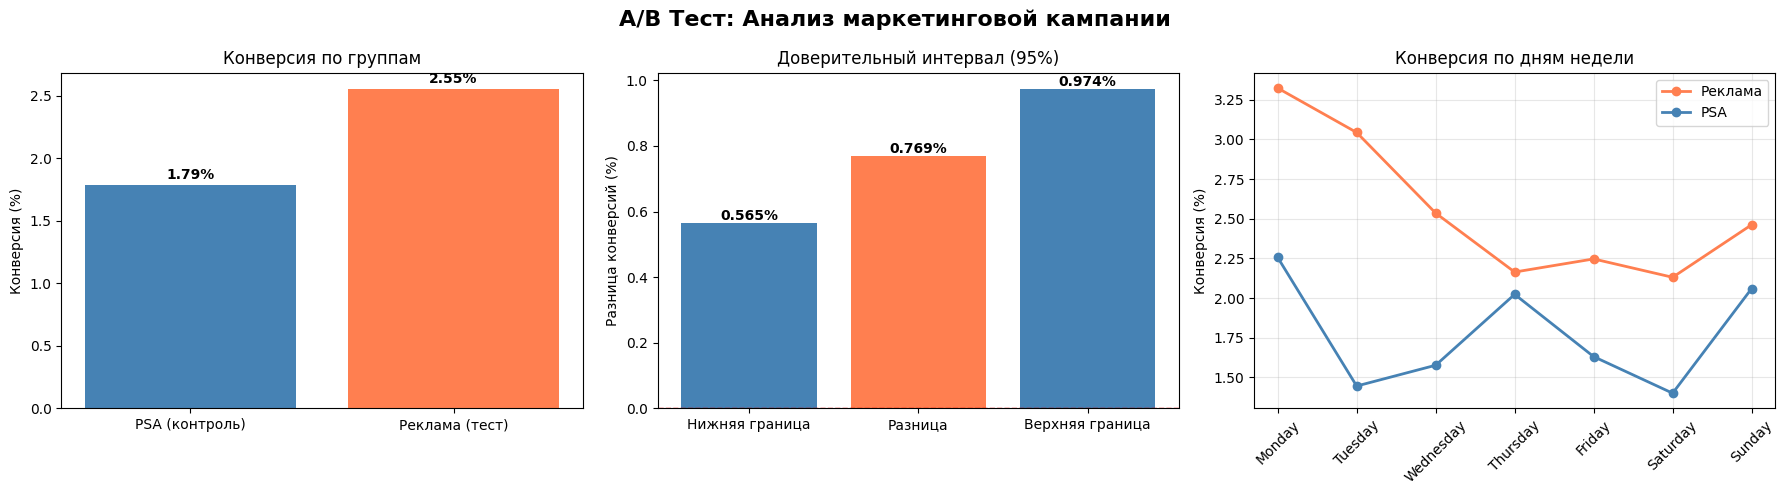

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('A/B Тест: Анализ маркетинговой кампании', fontsize=16, fontweight='bold')

axes[0].bar(['PSA (контроль)', 'Реклама (тест)'],
            [psa_rate*100, ad_rate*100],
            color=['steelblue', 'coral'])
axes[0].set_title('Конверсия по группам')
axes[0].set_ylabel('Конверсия (%)')
for i, v in enumerate([psa_rate*100, ad_rate*100]):
    axes[0].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')

axes[1].bar(['Нижняя граница', 'Разница', 'Верхняя граница'],
            [ci_lower*100, diff*100, ci_upper*100],
            color=['steelblue', 'coral', 'steelblue'])
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Доверительный интервал (95%)')
axes[1].set_ylabel('Разница конверсий (%)')
for i, v in enumerate([ci_lower*100, diff*100, ci_upper*100]):
    axes[1].text(i, v + 0.01, f'{v:.3f}%', ha='center', fontweight='bold')

day_conversion = df.groupby(['most_ads_day', 'test_group'])['converted'].mean().unstack()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_conversion = day_conversion.reindex(day_order)
x = range(len(day_order))
axes[2].plot(x, day_conversion['ad']*100, color='coral', marker='o', linewidth=2, label='Реклама')
axes[2].plot(x, day_conversion['psa']*100, color='steelblue', marker='o', linewidth=2, label='PSA')
axes[2].set_title('Конверсия по дням недели')
axes[2].set_xticks(x)
axes[2].set_xticklabels(day_order, rotation=45)
axes[2].set_ylabel('Конверсия (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Результаты A/B теста

| Метрика | PSA (контроль) | Реклама (тест) |
|---|---|---|
| Пользователей | 23,524 | 564,577 |
| Конверсий | 420 | 14,423 |
| Конверсия | 1.79% | 2.55% |

### Эффект рекламы
- Абсолютный прирост конверсии: **+0.769%**
- Относительный прирост: **+43.1%**
- Доверительный интервал (95%): **[0.565%, 0.974%]**